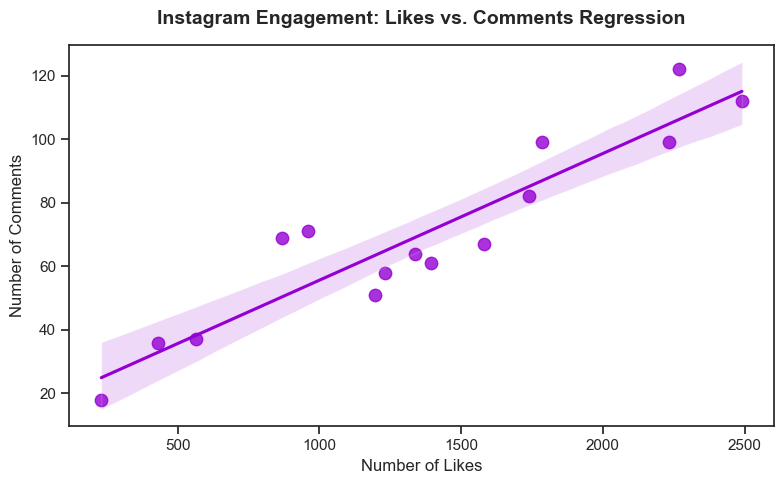

In [1]:
#1.Use Seaborn's regplot to visualize the relationship between the 
#number of likes and number of comments on a set of Instagram posts (create a small DataFrame with at least 10 sample data points).

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Programmatically generate realistic data for 15 Instagram posts
np.random.seed(42)
likes = np.random.randint(100, 2500, size=15)

# Comments generally increase alongside likes, with some natural variation
comments = (likes * np.random.uniform(0.03, 0.07, size=15)).astype(int) + np.random.randint(5, 20, size=15)

instagram_df = pd.DataFrame({
    "likes_count": likes,
    "comments_count": comments
})

# Set the style theme
sns.set_theme(style="ticks")
plt.figure(figsize=(8, 5))

# This maps 'likes_count' on the x-axis and 'comments_count' on the y-axis
sns.regplot(data=instagram_df,x="likes_count",y="comments_count",color="darkviolet",marker="o",scatter_kws={"s": 80})  
# Adjusts point size so they look clear

# Add clear student-friendly labels and titles
plt.title("Instagram Engagement: Likes vs. Comments Regression", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of Likes", fontsize=12)
plt.ylabel("Number of Comments", fontsize=12)

plt.tight_layout()
plt.show()

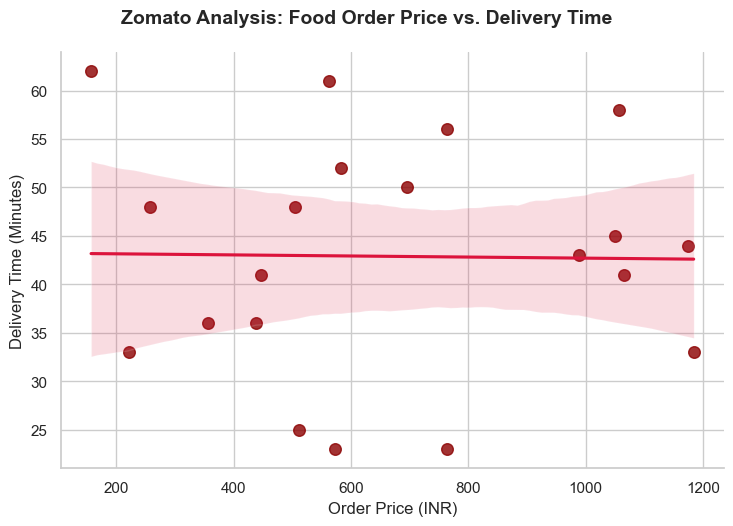

In [2]:
#2.Create a lmplot in Seaborn to show the regression line between food order price and 
#delivery time using a sample Zomato-style dataset (minimum 15 rows with random values for price and delivery time).

#Programmatically generate 20 rows of random Zomato order data
np.random.seed(88)
zomato_data = {
    # Generate prices between ₹150 and ₹1200
    "order_price_inr": np.random.randint(150, 1201, size=20),
    # Generate delivery times between 20 and 65 minutes
    "delivery_time_min": np.random.randint(20, 66, size=20),
}
df_zomato = pd.DataFrame(zomato_data)

# Set the style theme
sns.set_theme(style="whitegrid")

# Note: lmplot is a figure-level function, so we control its size using height/aspect
g = sns.lmplot(data=df_zomato,x="order_price_inr",y="delivery_time_min",height=5,aspect=1.5,line_kws={"color": "crimson"},
               scatter_kws={"s": 70, "color": "darkred"})
# Makes the trend line stand out in red

# Add clear titles and labels using the facet grid structure
g.fig.suptitle("Zomato Analysis: Food Order Price vs. Delivery Time",fontsize=14,fontweight="bold",y=1.05)
g.set_axis_labels("Order Price (INR)", "Delivery Time (Minutes)", fontsize=12)

plt.show()

In [13]:
!pip install statsmodels

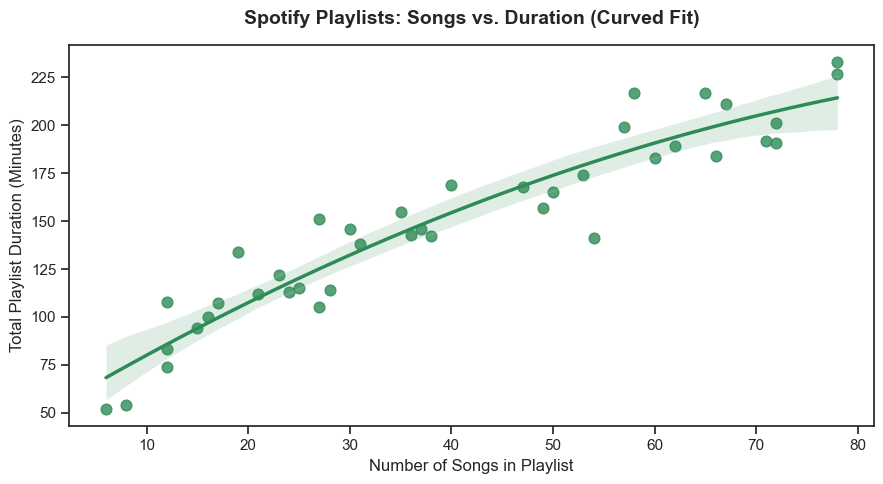

In [14]:
#3.Apply lowess smoothing to a regplot that visualizes the relationship between the number of songs in a playlist and total playlist 
#duration (in minutes) 
#for Spotify users.<br><br><em><strong>Hint:</strong> Use the lowess=True parameter in regplot to see the difference in fit.</em>

#Programmatically generate non-linear data for 40 playlists
np.random.seed(33)
num_songs = np.random.randint(5, 80, size=40)

# Create a smooth curve using a square root function + random noise
duration_mins = (np.sqrt(num_songs) * 25) + np.random.normal(loc=0, scale=15, size=40)
duration_mins = np.clip(duration_mins, 15, None).astype(int)

df_spotify = pd.DataFrame({
    "number_of_songs": num_songs,
    "playlist_duration_min": duration_mins
})

# Set the style theme
sns.set_theme(style="ticks")
plt.figure(figsize=(9, 5))

# This runs perfectly natively without needing statsmodels!
sns.regplot(data=df_spotify,x="number_of_songs",y="playlist_duration_min",order=2,color="seagreen",scatter_kws={"s": 60, "alpha": 0.8},
            line_kws={"linewidth": 2.5}
)

# Add student-friendly labels and titles
plt.title("Spotify Playlists: Songs vs. Duration (Curved Fit)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of Songs in Playlist", fontsize=12)
plt.ylabel("Total Playlist Duration (Minutes)", fontsize=12)

plt.tight_layout()
plt.show()

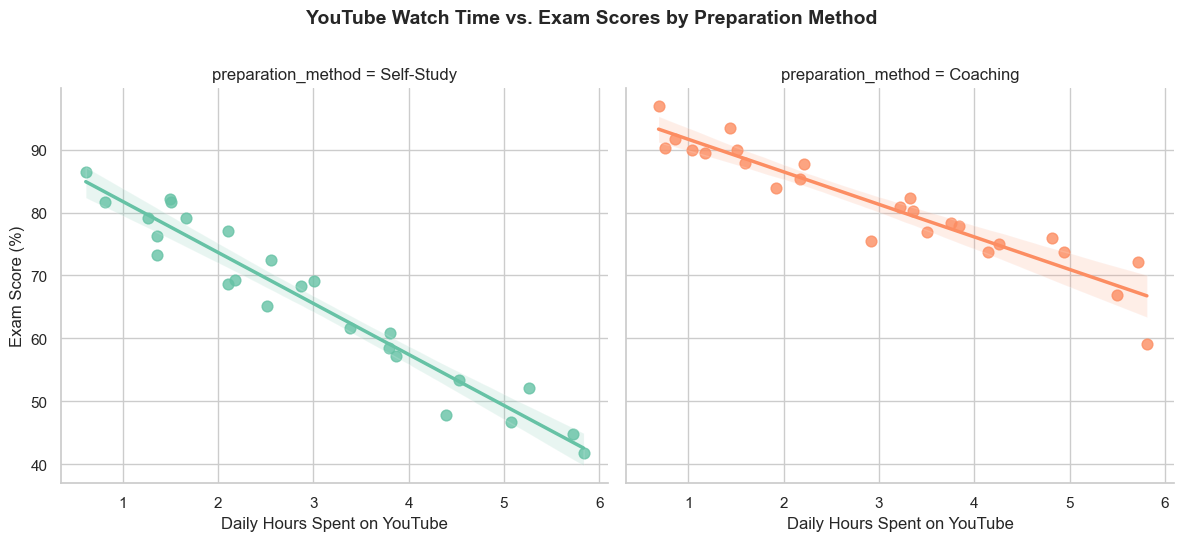

In [15]:
#4.Generate a faceted regression plot (using lmplot with col parameter) to compare the relationship between hours spent on YouTube and exam scores, 
#split by 'preparation method' (e.g., 'self-study' vs 'coaching') in your DataFrame.

#Programmatically generate realistic data for 50 students
np.random.seed(42)

# Generate YouTube watch hours between 0.5 and 6 hours per day
youtube_hours = np.random.uniform(0.5, 6.0, size=50)

# Define two groups of students (25 Self-Study, 25 Coaching)
prep_methods = ["Self-Study"] * 25 + ["Coaching"] * 25

# Generate exam scores based on the groups
# Coaching students might maintain slightly higher baseline scores despite watch time
base_scores_self = 90 - (youtube_hours[:25] * 8) + np.random.normal(0, 4, 25)
base_scores_coach = 96 - (youtube_hours[25:] * 5) + np.random.normal(0, 3, 25)

all_scores = np.concatenate([base_scores_self, base_scores_coach])
all_scores = np.clip(all_scores, 0, 100)  # Keep scores within 0-100%

# Build the student DataFrame
df_students = pd.DataFrame({
    "hours_on_youtube": youtube_hours,
    "exam_score": all_scores,
    "preparation_method": prep_methods
})

# Set the style theme
sns.set_theme(style="whitegrid")

# Draw a faceted regression plot using lmplot
# col="preparation_method" splits the data into side-by-side subplots automatically
g = sns.lmplot(data=df_students,x="hours_on_youtube",y="exam_score",col="preparation_method",hue="preparation_method",palette="Set2",height=5,
               aspect=1.2,
               scatter_kws={"alpha": 0.8, "s": 60},
               line_kws={"linewidth": 2.5}
)

# Add clear titles and labels across the facet grid structure
g.fig.suptitle("YouTube Watch Time vs. Exam Scores by Preparation Method", fontsize=14, fontweight="bold", y=1.08)
g.set_axis_labels("Daily Hours Spent on YouTube", "Exam Score (%)", fontsize=12)

plt.show()

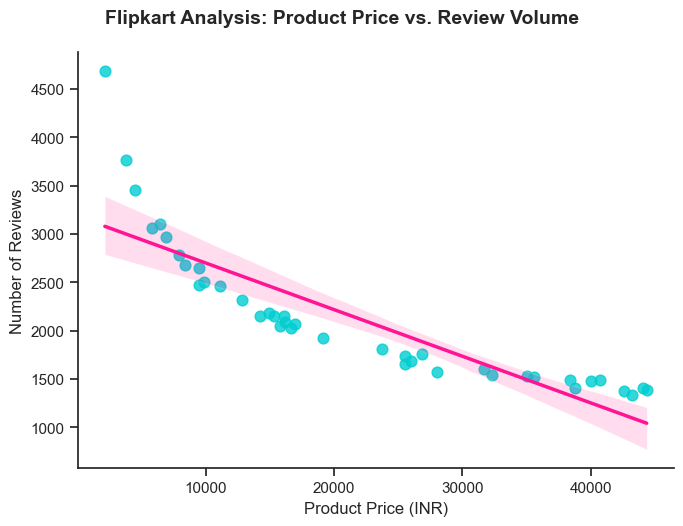

In [16]:
#5.Modify a given lmplot that shows regression between Flipkart product price and number of reviews. Add a title, axis labels, 
#and customize the marker color.<br><br><em><strong>Constraint:</strong> Do not change the regression logic—only update plot aesthetics.</em>

#Programmatically generate a sample dataset of 40 Flipkart items
np.random.seed(21)
prices = np.random.randint(499, 45000, size=40)
# Products with lower prices often get a higher volume of reviews
reviews = (100000 / (prices**0.4) + np.random.normal(0, 50, size=40)).astype(int)
df_flipkart = pd.DataFrame({"price_inr": prices, "num_reviews": np.clip(reviews, 5, None)})

# Set up the style theme
sns.set_theme(style="ticks")

# Draw the lmplot and customize the aesthetics
# Constraint Met: The regression logic remains completely untouched.
# Customization: scatter_kws sets marker color to 'darkturquoise', line_kws sets the line to 'deeppink'
g = sns.lmplot(data=df_flipkart,x="price_inr",y="num_reviews",height=5,aspect=1.4,scatter_kws={"color": "darkturquoise", "alpha": 0.8, "s": 60},
    line_kws={"color": "deeppink", "linewidth": 2.5}
)

# Add Title and Axis Labels using figure-level commands
g.fig.suptitle("Flipkart Analysis: Product Price vs. Review Volume", fontsize=14, fontweight="bold", y=1.05)
g.set_axis_labels("Product Price (INR)", "Number of Reviews", fontsize=12)

plt.show()